# Notebook 07: Bias Correction
Opx ML Thermobarometer
Author: [Your name]
Date: 2026-04-04

This notebook applies bias correction to reduce regression-to-the-mean effects in ML predictions.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
from config import (ROOT, DATA_RAW, DATA_PROC, DATA_SPLITS, DATA_NATURAL,
                    MODELS, FIGURES, RESULTS, LOGS, EXPETDB)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import joblib
import warnings
warnings.filterwarnings('ignore')

## 7.1 Load training data and fit bias correction

In [2]:
df_liq_full = pd.read_parquet(DATA_PROC / 'opx_clean_opx_liq.parquet')
train_idx = np.load(DATA_SPLITS / 'train_indices_opx_liq.npy')

OPX_FEAT = ['SiO2','Al2O3','FeO_total','MgO','CaO','Mg_num','Al_IV','Al_VI','En_frac','Fs_frac','Wo_frac','MgTs']
LIQ_OXIDES = ['SiO2','TiO2','Al2O3','FeO','MgO','CaO','Na2O','K2O']
liq_feat = [f'liq_{o}' for o in LIQ_OXIDES] + ['liq_Mg_num']
ALL_FEAT = OPX_FEAT + liq_feat

df_train_liq = df_liq_full.loc[train_idx].copy()
X_train = df_train_liq[ALL_FEAT].fillna(0).values
y_train_T = df_train_liq['T_C'].values
y_train_P = df_train_liq['P_kbar'].values

model_T = joblib.load(MODELS / 'model_RF_T_C_opx_liq.joblib')
model_P = joblib.load(MODELS / 'model_RF_P_kbar_opx_liq.joblib')

train_pred_T = model_T.predict(X_train)
train_pred_P = model_P.predict(X_train)

bias_model_T = LinearRegression()
residuals_T = y_train_T - train_pred_T
bias_model_T.fit(train_pred_T.reshape(-1, 1), residuals_T)
a_T, b_T = bias_model_T.coef_[0], bias_model_T.intercept_

bias_model_P = LinearRegression()
residuals_P = y_train_P - train_pred_P
bias_model_P.fit(train_pred_P.reshape(-1, 1), residuals_P)
a_P, b_P = bias_model_P.coef_[0], bias_model_P.intercept_

print(f'Training set: {len(df_train_liq)} opx-liq pairs')
print(f'Temperature correction: residual = {a_T:.4f} * pred + {b_T:.2f}')
print(f'Pressure correction: residual = {a_P:.4f} * pred + {b_P:.2f}')

Training set: 439 opx-liq pairs
Temperature correction: residual = 0.0371 * pred + -45.99
Pressure correction: residual = 0.0783 * pred + -0.93


## 7.2 Apply correction to test set and evaluate

In [3]:
test_idx = np.load(DATA_SPLITS / 'test_indices_opx_liq.npy')
df_test_liq = df_liq_full.loc[test_idx].copy()
X_test = df_test_liq[ALL_FEAT].fillna(0).values
y_test_T = df_test_liq['T_C'].values
y_test_P = df_test_liq['P_kbar'].values

test_pred_T_raw = model_T.predict(X_test)
test_pred_P_raw = model_P.predict(X_test)

test_pred_T_corr = test_pred_T_raw + (a_T * test_pred_T_raw + b_T)
test_pred_P_corr = test_pred_P_raw + (a_P * test_pred_P_raw + b_P)

rmse_T_raw = np.sqrt(mean_squared_error(y_test_T, test_pred_T_raw))
rmse_T_corr = np.sqrt(mean_squared_error(y_test_T, test_pred_T_corr))
rmse_P_raw = np.sqrt(mean_squared_error(y_test_P, test_pred_P_raw))
rmse_P_corr = np.sqrt(mean_squared_error(y_test_P, test_pred_P_corr))

print(f'Test set: {len(df_test_liq)} opx-liq pairs')
print(f'Temperature: Raw RMSE = {rmse_T_raw:.2f} C, Corrected = {rmse_T_corr:.2f} C')
print(f'Pressure: Raw RMSE = {rmse_P_raw:.2f} kbar, Corrected = {rmse_P_corr:.2f} kbar')

Test set: 170 opx-liq pairs
Temperature: Raw RMSE = 124.02 C, Corrected = 124.37 C
Pressure: Raw RMSE = 6.14 kbar, Corrected = 5.98 kbar


## 7.3 Create residual plots (Fig 11)

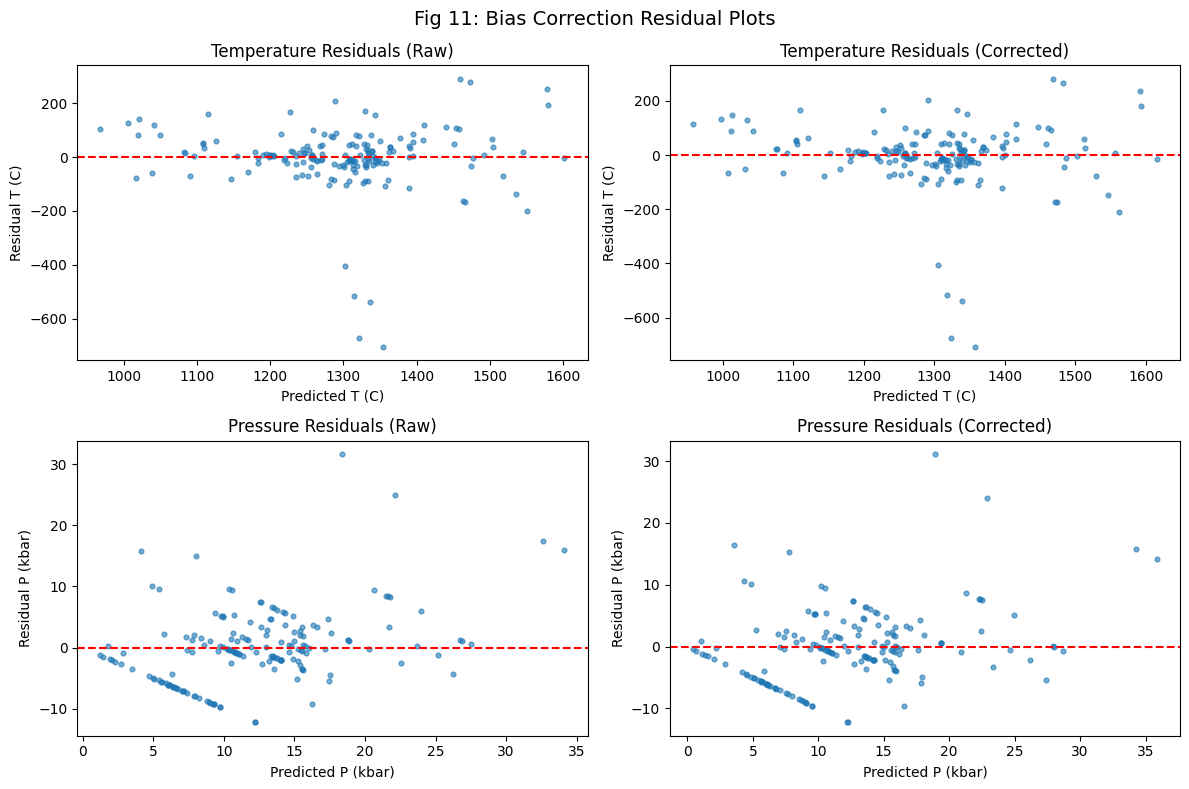

Saved fig11_bias_correction_residuals.png



Notebook 07 complete.


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

residuals_T_raw = y_test_T - test_pred_T_raw
residuals_T_corr = y_test_T - test_pred_T_corr

axes[0, 0].scatter(test_pred_T_raw, residuals_T_raw, alpha=0.6, s=12)
axes[0, 0].axhline(0, color='red', ls='--')
axes[0, 0].set_xlabel('Predicted T (C)')
axes[0, 0].set_ylabel('Residual T (C)')
axes[0, 0].set_title('Temperature Residuals (Raw)')

axes[0, 1].scatter(test_pred_T_corr, residuals_T_corr, alpha=0.6, s=12)
axes[0, 1].axhline(0, color='red', ls='--')
axes[0, 1].set_xlabel('Predicted T (C)')
axes[0, 1].set_ylabel('Residual T (C)')
axes[0, 1].set_title('Temperature Residuals (Corrected)')

residuals_P_raw = y_test_P - test_pred_P_raw
residuals_P_corr = y_test_P - test_pred_P_corr

axes[1, 0].scatter(test_pred_P_raw, residuals_P_raw, alpha=0.6, s=12)
axes[1, 0].axhline(0, color='red', ls='--')
axes[1, 0].set_xlabel('Predicted P (kbar)')
axes[1, 0].set_ylabel('Residual P (kbar)')
axes[1, 0].set_title('Pressure Residuals (Raw)')

axes[1, 1].scatter(test_pred_P_corr, residuals_P_corr, alpha=0.6, s=12)
axes[1, 1].axhline(0, color='red', ls='--')
axes[1, 1].set_xlabel('Predicted P (kbar)')
axes[1, 1].set_ylabel('Residual P (kbar)')
axes[1, 1].set_title('Pressure Residuals (Corrected)')

plt.suptitle('Fig 11: Bias Correction Residual Plots', fontsize=14, y=0.98)
plt.tight_layout()
plt.savefig(FIGURES / 'fig11_bias_correction_residuals.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close()
print('Saved fig11_bias_correction_residuals.png')

joblib.dump({'model': model_T, 'a': a_T, 'b': b_T}, MODELS / 'model_RF_T_C_opx_liq_corrected.joblib')
joblib.dump({'model': model_P, 'a': a_P, 'b': b_P}, MODELS / 'model_RF_P_kbar_opx_liq_corrected.joblib')

print('\nNotebook 07 complete.')